# Running an EDA on the updated dataset provided by the [HHS Open Data Platform](https://opendata.hhs.gov/datasets/medicaid-provider-spending/)

This analysis focuses on understanding the NULL values in the new version of the dataset. The older version had no NULL values for billing provider NPI or servicing provider NPI, but the new version contains a notable share of rows where these fields are NULL. Although they represent a small percentage of total row count, the amounts paid in those rows vary significantly — warranting a closer look before using this dataset for analysis.


In [7]:
import duckdb
import polars as pl
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

duckdb_path = '/Users/adilkassim/Downloads/medicaid-provider-spending.duckdb'
con = duckdb.connect(f"{duckdb_path}")



In [8]:
## First 20 Rows
con.sql("select * from dataset limit 20")


┌──────────────────────────┬────────────────────────────┬────────────┬──────────────────┬────────────────┬───────────────────┬──────────────────┐
│ BILLING_PROVIDER_NPI_NUM │ SERVICING_PROVIDER_NPI_NUM │ HCPCS_CODE │ CLAIM_FROM_MONTH │ TOTAL_PATIENTS │ TOTAL_CLAIM_LINES │    TOTAL_PAID    │
│         varchar          │          varchar           │  varchar   │     varchar      │     int64      │       int64       │      double      │
├──────────────────────────┼────────────────────────────┼────────────┼──────────────────┼────────────────┼───────────────────┼──────────────────┤
│ NULL                     │ 5200000300                 │ 20         │ 2018-06          │            915 │              8403 │ 7469333333258.64 │
│ NULL                     │ 5200000300                 │ 20         │ 2018-01          │            874 │              7368 │ 6549333333267.84 │
│ NULL                     │ 5200000300                 │ 20         │ 2018-02          │            878 │              6962

Surprising to see rows missing a billing provider NPI and even more surprising to see rows missing both billing and servicing provider NPIs as the older dataset had no missing NPIs. 

Let's investigate the missing NPIs and see if we can find any patterns or reasons for their absence.


In [9]:
con.sql("""
SELECT
    (BILLING_PROVIDER_NPI_NUM IS NULL) AS billing_null,
    (SERVICING_PROVIDER_NPI_NUM IS NULL) AS servicing_null,
    COUNT(*) as num_of_rows,
    SUM(TOTAL_PAID) as total_paid
FROM dataset
GROUP BY all
"""
)

┌──────────────┬────────────────┬─────────────┬────────────────────┐
│ billing_null │ servicing_null │ num_of_rows │     total_paid     │
│   boolean    │    boolean     │    int64    │       double       │
├──────────────┼────────────────┼─────────────┼────────────────────┤
│ false        │ false          │   221375333 │ 1003056531501.6927 │
│ false        │ true           │     8834087 │ 101591461189.01503 │
│ true         │ false          │     7532557 │ 20323545953161.992 │
│ true         │ true           │      273752 │   371205742714.148 │
└──────────────┴────────────────┴─────────────┴────────────────────┘

In [10]:
con.sql("""
SELECT
    (BILLING_PROVIDER_NPI_NUM IS NULL) AS billing_null,
    (SERVICING_PROVIDER_NPI_NUM IS NULL) AS servicing_null,
    COUNT(*) as num_of_rows,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct,
    SUM(TOTAL_PAID) as total_paid,
    ROUND(SUM(TOTAL_PAID) * 100.0 / SUM(SUM(TOTAL_PAID)) OVER (), 2) as paid_pct
FROM
    dataset
group by all
"""
)

┌──────────────┬────────────────┬─────────────┬────────┬────────────────────┬──────────┐
│ billing_null │ servicing_null │ num_of_rows │  pct   │     total_paid     │ paid_pct │
│   boolean    │    boolean     │    int64    │ double │       double       │  double  │
├──────────────┼────────────────┼─────────────┼────────┼────────────────────┼──────────┤
│ false        │ false          │   221375333 │  93.01 │  1003056531503.594 │      4.6 │
│ true         │ false          │     7532557 │   3.16 │  20323545953175.35 │    93.23 │
│ false        │ true           │     8834087 │   3.71 │ 101591461189.01752 │     0.47 │
│ true         │ true           │      273752 │   0.12 │ 371205742714.14606 │      1.7 │
└──────────────┴────────────────┴─────────────┴────────┴────────────────────┴──────────┘

The majority of rows (93.01%) have both NPIs present. The troubling aspect is that rows missing only a billing provider NPI account for 93.23% of total payments — roughly $20 trillion. This does not make sense, as total annual Medicaid spending is well under $1 trillion.

Let's plot the data to see how it looks — visualizing it may reveal anomalies more clearly.

<Axes: xlabel='year'>

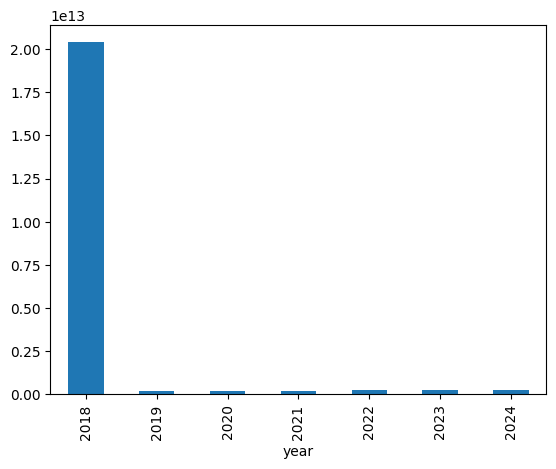

In [11]:
per_year = con.sql("""
SELECT
    SUBSTR(CLAIM_FROM_MONTH, 1, 4) AS year,
    SUM(TOTAL_PAID) AS TOTAL_PAID
FROM dataset
GROUP BY year
ORDER BY year
""").to_df()

per_year.plot.bar(x="year", y="TOTAL_PAID", legend=False)


In [12]:
for _, row in per_year.iterrows():
    print(f"{row['year']}: {row['TOTAL_PAID']}")
    


2018: 20383877394608.215
2019: 222929227068.12366
2020: 182725957403.39767
2021: 220840385815.96652
2022: 244655272048.03278
2023: 276433297242.3397
2024: 267938154373.6155


Clearly something is wrong in 2018 — over $20 trillion appears to have been distributed that year alone.

Let's examine by month in 2018 to see if we can identify when the issue starts.

In [13]:
per_month = con.sql("""
SELECT
    sum(total_paid) as TOTAL_PAID, 
    CLAIM_FROM_MONTH
FROM
    dataset
WHERE SUBSTR(CLAIM_FROM_MONTH, 1, 4) = '2018'
GROUP BY CLAIM_FROM_MONTH
order by  CLAIM_FROM_MONTH
"""
).to_df()

In [14]:
per_month

,TOTAL_PAID,CLAIM_FROM_MONTH
0,6.562095e+12,2018-01
1,6.200209e+12,2018-02
2,1.271733e+10,2018-03
3,1.432379e+10,2018-04
4,1.488778e+10,2018-05
5,7.481644e+12,2018-06
6,1.612801e+10,2018-07
7,2.134688e+10,2018-08
8,1.767347e+10,2018-09
9,1.651839e+10,2018-10


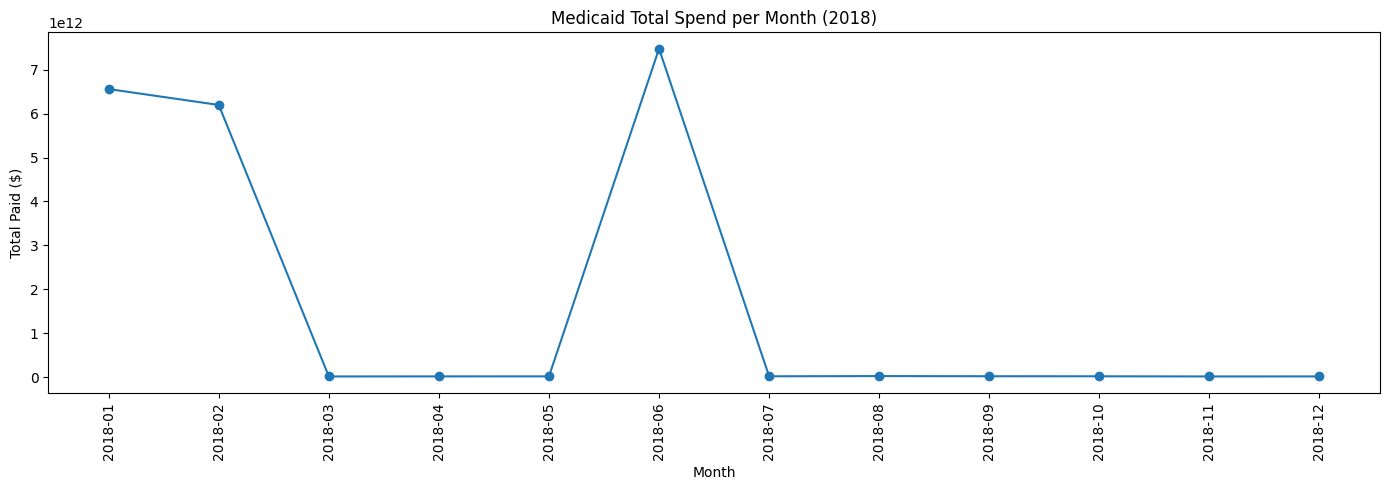

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(per_month["CLAIM_FROM_MONTH"], per_month["TOTAL_PAID"], marker="o", linewidth=1.5)
ax.set_xlabel("Month")
ax.set_ylabel("Total Paid ($)")
ax.set_title("Medicaid Total Spend per Month (2018)")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

Clearly something is wrong with the data, specifically in 2018.
The data providers appear to have been aware of this issue — in their example visualization, they only plotted data starting from October 2018, which is when the figures start to look more reasonable. They also filter to rows where both billing and servicing provider NPIs are present.
Let's recreate their visualization.

In [16]:
per_month_after_sep = con.sql("""
SELECT
    sum(total_paid) as TOTAL_PAID, 
    CLAIM_FROM_MONTH
FROM
    dataset
WHERE CLAIM_FROM_MONTH > '2018-09'
AND BILLING_PROVIDER_NPI_NUM is NOT NULL
AND SERVICING_PROVIDER_NPI_NUM IS NOT NULL 
GROUP BY CLAIM_FROM_MONTH
order by  CLAIM_FROM_MONTH
"""
).to_df()

In [17]:
avg_per_month = per_month_after_sep['TOTAL_PAID'].mean()

In [18]:
per_month_after_sep

,TOTAL_PAID,CLAIM_FROM_MONTH
0,9.246470e+09,2018-10
1,8.457151e+09,2018-11
2,8.267035e+09,2018-12
3,9.821253e+09,2019-01
4,9.025005e+09,2019-02
...,...,...
70,1.501142e+10,2024-08
71,1.432105e+10,2024-09
72,1.491811e+10,2024-10
73,1.161741e+10,2024-11


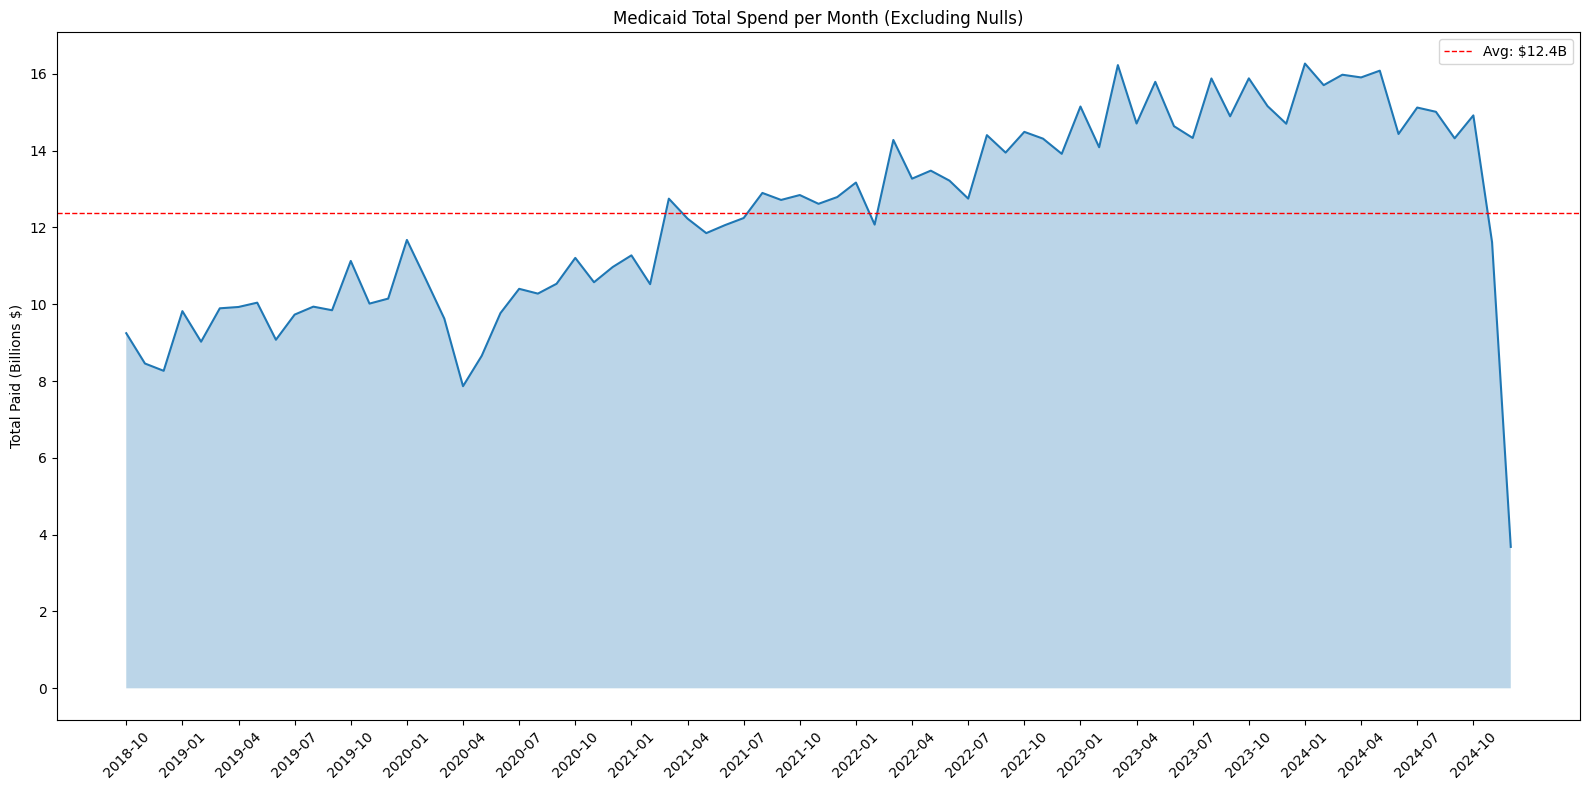

In [19]:
per_month_after_sep = per_month_after_sep.sort_values("CLAIM_FROM_MONTH").reset_index(drop=True)
# change step if you want to see less ticks. rather than have it show for each show every other month, step = 2
step = 3
fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(per_month_after_sep["CLAIM_FROM_MONTH"], per_month_after_sep["TOTAL_PAID"] / 1e9)
ax.fill_between(per_month_after_sep["CLAIM_FROM_MONTH"], per_month_after_sep["TOTAL_PAID"] / 1e9, alpha=0.3)
avg = per_month_after_sep["TOTAL_PAID"].mean() / 1e9
ax.axhline(avg, color="red", linestyle="--", linewidth=1, label=f"Avg: ${avg:.1f}B")
ax.legend()
ax.set_xticks(range(0, len(per_month_after_sep), step))
ax.set_xticklabels(per_month_after_sep["CLAIM_FROM_MONTH"][::step], rotation=45)
ax.set_ylabel("Total Paid (Billions $)")
ax.set_title("Medicaid Total Spend per Month (Excluding Nulls)")


plt.tight_layout()
plt.show()


Nearly identical to the example visualization provided by the data providers. The only difference is they chose to end the x-axis at September 2024, while I extended it through end of 2024 — and we can see a sharp decline in the data toward the end of 2024. This could be a data quality issue they chose not to highlight, or it may simply be that the data is incomplete for late 2024.
Let's visualize the data with all rows, including those with missing NPIs, to see how it compares.

In [ ]:
all_rows = con.sql("""
SELECT
    sum(total_paid) as TOTAL_PAID, 
    CLAIM_FROM_MONTH
FROM
    dataset
WHERE CLAIM_FROM_MONTH > '2018-09'
GROUP BY CLAIM_FROM_MONTH
order by  CLAIM_FROM_MONTH
"""
).to_df()

In [ ]:
all_rows = all_rows.sort_values("CLAIM_FROM_MONTH").reset_index(drop=True)

avg = all_rows["TOTAL_PAID"].mean() / 1e9
step = 3
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(all_rows["CLAIM_FROM_MONTH"], all_rows["TOTAL_PAID"] / 1e9)
ax.fill_between(all_rows["CLAIM_FROM_MONTH"], all_rows["TOTAL_PAID"] / 1e9, alpha=0.3)
ax.axhline(avg, color="red", linestyle="--", linewidth=1, label=f"Avg: ${avg:.1f}B")
ax.set_xticks(range(0, len(all_rows), step))
ax.set_xticklabels(all_rows["CLAIM_FROM_MONTH"][::step], rotation=45)
ax.set_ylabel("Total Paid (Billions $)")
ax.set_title("Medicaid Total Spend per Month")
ax.legend()
plt.tight_layout()
plt.show()

The graphs look significantly different when rows with NULL billing or servicing provider NPIs are included.
Average monthly spend is noticeably higher when those rows are included, suggesting the missing NPIs are not random — they appear to be associated with disproportionately large payments. This could be due to data entry errors, or it may be that certain provider types or services are more expensive and are more likely to have missing identifiers.

In [22]:
con.sql("""
SELECT
    (BILLING_PROVIDER_NPI_NUM IS NULL) AS billing_null,
    (SERVICING_PROVIDER_NPI_NUM IS NULL) AS servicing_null,
    COUNT(*) as cnt,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as cnt_pct,
    SUM(TOTAL_PAID) as total_paid,
    ROUND(SUM(TOTAL_PAID) * 100.0 / SUM(SUM(TOTAL_PAID)) OVER (), 2) as paid_pct,
    max(TOTAL_PAID), MIN(TOTAL_PAID), AVG(TOTAL_PAID), MEDIAN(TOTAL_PAID)
FROM dataset
GROUP BY 1, 2
ORDER BY cnt DESC
""")

┌──────────────┬────────────────┬───────────┬─────────┬────────────────────┬──────────┬──────────────────┬─────────────────┬────────────────────┬────────────────────┐
│ billing_null │ servicing_null │    cnt    │ cnt_pct │     total_paid     │ paid_pct │ max(TOTAL_PAID)  │ min(TOTAL_PAID) │  avg(TOTAL_PAID)   │ median(TOTAL_PAID) │
│   boolean    │    boolean     │   int64   │ double  │       double       │  double  │      double      │     double      │       double       │       double       │
├──────────────┼────────────────┼───────────┼─────────┼────────────────────┼──────────┼──────────────────┼─────────────────┼────────────────────┼────────────────────┤
│ false        │ false          │ 221375333 │   93.01 │  1003056531503.544 │      4.6 │     118999818.09 │      -113643.78 │  4531.022123876574 │             621.14 │
│ false        │ true           │   8834087 │    3.71 │ 101591461189.02374 │     0.47 │      27095930.55 │      -183021.84 │ 11499.938951135951 │             517.25 

The median total paid when both NPIs are missing ($963.62) is roughly 55% higher than when both are present ($621.14).

Notably, the most frequent HCPCS codes in the both-null group are 99213, 99214, 99283, 99284, and 99285 — the same high-volume office visit and ED codes that top the list when both NPIs are present. This rules out intentional anonymisation and strongly suggests a data submission failure where provider identifiers were simply dropped on otherwise normal claims.

For this reason, we will work with the older dataset going forward, as it is complete and does not have this issue.

## HCPS Codes

In [30]:
con.sql("""
SELECT
    HCPCS_CODE, 
    Count(HCPCS_CODE)
FROM
    dataset

WHERE BILLING_PROVIDER_NPI_NUM is NOT NULL
AND SERVICING_PROVIDER_NPI_NUM IS NOT NULL 
GROUP BY HCPCS_CODE
ORDER BY COUNT(HCPCS_CODE) DESC
"""
)

┌────────────┬───────────────────┐
│ HCPCS_CODE │ count(HCPCS_CODE) │
│  varchar   │       int64       │
├────────────┼───────────────────┤
│ 99213      │          13642976 │
│ 99214      │          11852216 │
│ 99284      │           4059022 │
│ 99283      │           3339268 │
│ 99285      │           2935154 │
│ 36415      │           2713536 │
│ T1015      │           2373185 │
│ 85025      │           2236155 │
│ D0120      │           2234387 │
│ 90837      │           1872580 │
│   ·        │                 · │
│   ·        │                 · │
│   ·        │                 · │
│ E2368      │                 1 │
│ L8320      │                 1 │
│ 908HW      │                 1 │
│ T2130      │                 1 │
│ 82585      │                 1 │
│ 3074       │                 1 │
│ 83805      │                 1 │
│ 53600      │                 1 │
│ Z0126      │                 1 │
│ P2031      │                 1 │
└────────────┴───────────────────┘
  ? rows            

In [25]:
per_month_after_sep

,count(HCPCS_CODE)
0,3339268
1,7554
2,100924
3,2236155
4,69158
...,...
10728,1
10729,1
10730,1
10731,1
